In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
# Load the dataset
df = pd.read_csv("Bank Customer Details (1).csv")

In [15]:
# Clean column names
df.columns = df.columns.str.strip()

In [17]:
# Convert Balance to numeric
df['Balance'] = pd.to_numeric(df['Balance'], errors='coerce')
df = df.dropna(subset=['Balance'])

In [19]:
# Create the target variable
df['High Balance'] = (df['Balance'] > 50000).astype(int)

In [21]:
# Select features
X = df[['Gender', 'Age', 'Region', 'Job Classification']].copy()
y = df['High Balance']

In [25]:
# Encode categorical features
le_gender = LabelEncoder()
le_region = LabelEncoder()
le_job = LabelEncoder()

X['Gender'] = le_gender.fit_transform(X['Gender'])
X['Region'] = le_region.fit_transform(X['Region'])
X['Job Classification'] = le_job.fit_transform(X['Job Classification'])

In [27]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Train Random Forest with class_weight to handle imbalance
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [33]:
# Predict and evaluate
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))

Accuracy: 0.5379825653798257

Confusion Matrix:
 [[329 206]
 [165 103]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.61      0.64       535
           1       0.33      0.38      0.36       268

    accuracy                           0.54       803
   macro avg       0.50      0.50      0.50       803
weighted avg       0.55      0.54      0.55       803



In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

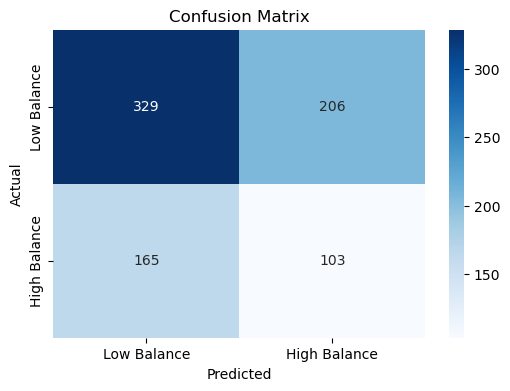

In [37]:
# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Balance', 'High Balance'], yticklabels=['Low Balance', 'High Balance'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [39]:
# Plot Feature Importances
importances = model.feature_importances_
feature_names = X.columns
feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)

C:\Users\DELL\AppData\Local\Temp\ipykernel_55324\460885326.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance_df, palette='viridis')


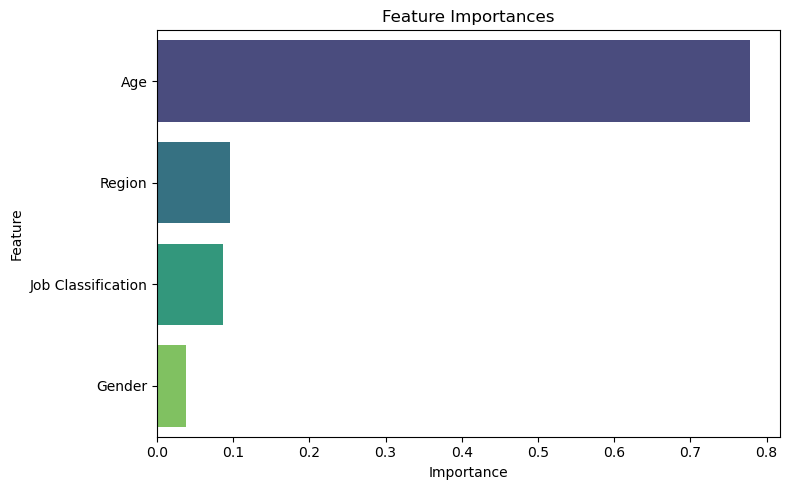

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df, palette='viridis')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_55324\3260304938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='High Balance', data=df, palette='Set2')


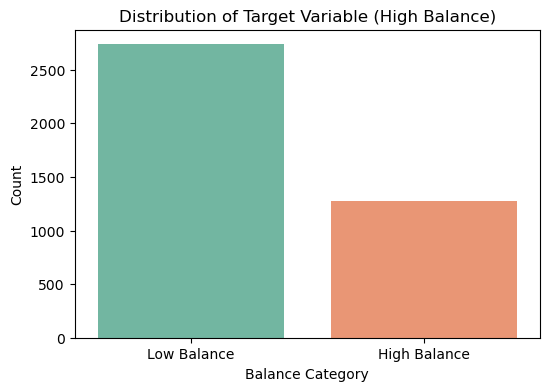

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(x='High Balance', data=df, palette='Set2')
plt.title('Distribution of Target Variable (High Balance)')
plt.xticks([0, 1], ['Low Balance', 'High Balance'])
plt.xlabel('Balance Category')
plt.ylabel('Count')
plt.show()

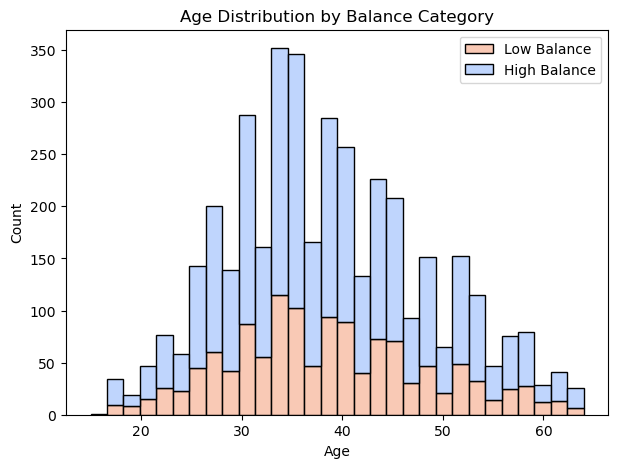

In [45]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Age', hue='High Balance', multiple='stack', palette='coolwarm', bins=30)
plt.title('Age Distribution by Balance Category')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['Low Balance', 'High Balance'])
plt.show()

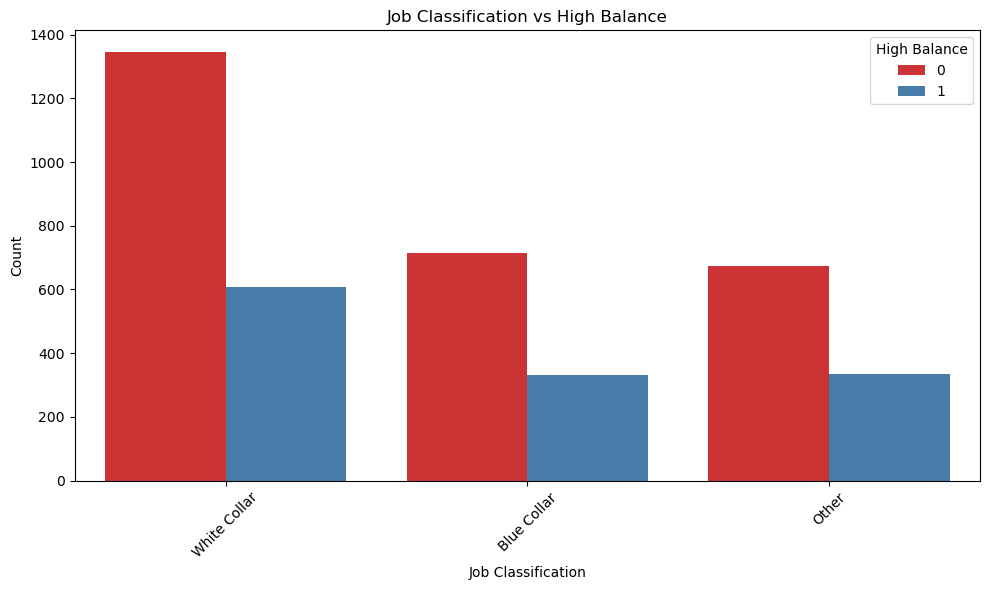

In [47]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Job Classification', hue='High Balance', palette='Set1')
plt.title('Job Classification vs High Balance')
plt.xticks(rotation=45)
plt.xlabel('Job Classification')
plt.ylabel('Count')
plt.legend(title='High Balance')
plt.tight_layout()
plt.show()

In [49]:
from sklearn.metrics import roc_curve, auc

y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

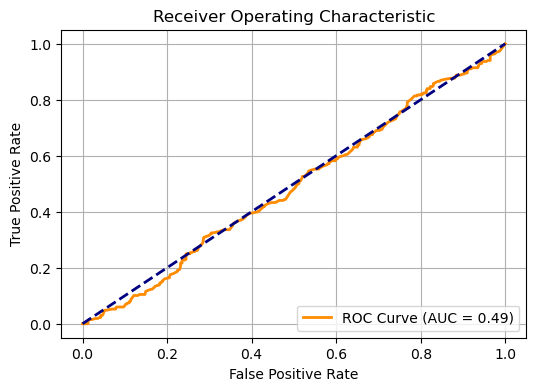

In [51]:
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [55]:
# Save the DataFrame with the new 'High Balance' column
df.to_csv('Updated_Bank_Customer_Details.csv',index=False)

In [57]:
df

,Customer ID,Name,Surname,Gender,Age,Region,Job Classification,Date Joined,Balance,High Balance
0,100000001,Simon,Walsh,Male,21,England,White Collar,05.Jan.15,113810.15,1
1,400000002,Jasmine,Miller,Female,34,Northern Ireland,Blue Collar,06.Jan.15,36919.73,0
2,100000003,Liam,Brown,Male,46,England,White Collar,07.Jan.15,101536.83,1
3,300000004,Trevor,Parr,Male,32,Wales,White Collar,08.Jan.15,1421.52,0
4,100000005,Deirdre,Pullman,Female,38,England,Blue Collar,09.Jan.15,35639.79,0
...,...,...,...,...,...,...,...,...,...,...
4009,200004010,Sam,Lewis,Male,64,Scotland,Other,30.Dec.15,19711.66,0
4010,200004011,Keith,Hughes,Male,52,Scotland,Blue Collar,30.Dec.15,56069.72,1
4011,200004012,Hannah,Springer,Female,50,Scotland,Other,30.Dec.15,59477.82,1
4012,200004013,Christian,Reid,Male,51,Scotland,Blue Collar,30.Dec.15,239.45,0
